<a href="https://colab.research.google.com/github/AkhilaSunesh/Epoch_Data_Science_Bootcamp/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 6
**Name:** Akhila Sunesh <br>
**Date:** 28th July 2026 <br>
**Time:** 03:01pm <br>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


In [2]:
df = pd.read_csv('customer_churn_dataset-training-master.csv')
print("Shape:", df.shape)
df.head()


Shape: (440833, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [4]:
df.describe(include='all')


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832,440832.000000,440832.000000,440832.000000,440832.000000,440832,440832,440832.000000,440832.000000,440832.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,Standard,Annual,NaN,NaN,NaN
freq,NaN,NaN,250252,NaN,NaN,NaN,NaN,149128,177198,NaN,NaN,NaN
mean,225398.667955,39.373153,NaN,31.256336,15.807494,3.604437,12.965722,NaN,NaN,631.616223,14.480868,0.567107
std,129531.918550,12.442369,NaN,17.255727,8.586242,3.070218,8.258063,NaN,NaN,240.803001,8.596208,0.495477
min,2.000000,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,NaN,16.000000,9.000000,1.000000,6.000000,NaN,NaN,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,NaN,32.000000,16.000000,3.000000,12.000000,NaN,NaN,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,NaN,46.000000,23.000000,6.000000,19.000000,NaN,NaN,830.000000,22.000000,1.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


Target distribution:
Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


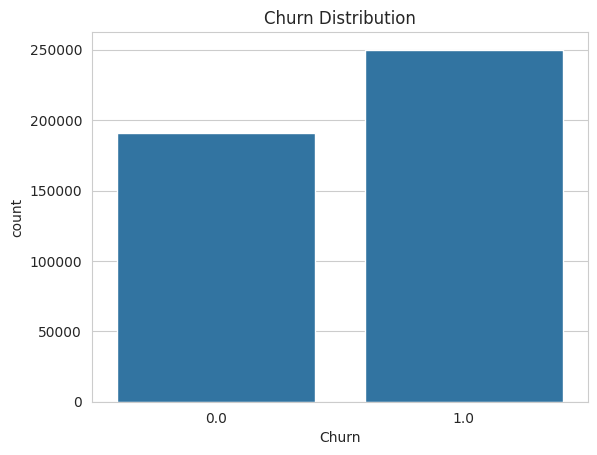

In [6]:
print("Target distribution:")
print(df['Churn'].value_counts())
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()


In [7]:
# Drop fully-empty rows (data artifact — 1 row with all NaNs)
df = df.dropna(how='all')

# Drop identifier column (not predictive)
df = df.drop(columns=['CustomerID'])

print("Shape after dropping empty rows and CustomerID:", df.shape)
print(df.isnull().sum())


Shape after dropping empty rows and CustomerID: (440832, 11)
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [8]:
# Handle any remaining missing values
num_cols = df.select_dtypes(include=[np.number]).columns.drop('Churn')
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

df['Churn'] = df['Churn'].astype(int)
print(df.isnull().sum().sum(), "missing values remaining")


0 missing values remaining


In [9]:
# Encode categorical features
label_encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    label_encoders[c] = le

df.head()


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,2,0,932.0,17.0,1
1,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1
2,55.0,0,14.0,4.0,6.0,18.0,0,2,185.0,3.0,1
3,58.0,1,38.0,21.0,7.0,7.0,2,1,396.0,29.0,1
4,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1


In [10]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (352665, 10) Test shape: (88167, 10)


In [11]:
# Feature scaling (needed for Logistic Regression; tree-based models are scale-invariant
# but we scale the shared feature set once for consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
models = {}

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = (log_reg, X_test_scaled)

dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
models['Decision Tree'] = (dt, X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = (rf, X_test)

print("Models trained:", list(models.keys()))


Models trained: ['Logistic Regression', 'Decision Tree', 'Random Forest']


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.83     38167
           1       0.88      0.86      0.87     50000

    accuracy                           0.85     88167
   macro avg       0.85      0.85      0.85     88167
weighted avg       0.85      0.85      0.85     88167



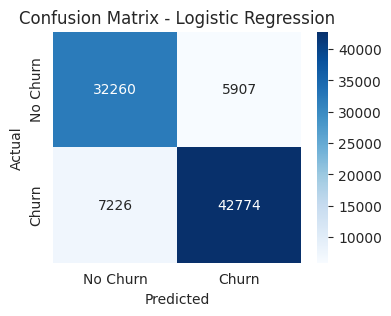

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     38167
           1       1.00      0.99      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



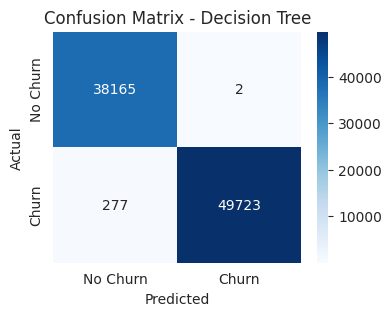

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38167
           1       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



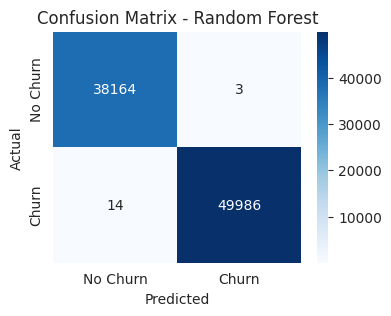

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.999807,0.999940,0.99972,0.999830
1,Decision Tree,0.996836,0.999960,0.99446,0.997202
2,Logistic Regression,0.851044,0.878659,0.85548,0.866915


In [14]:
results = []

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df


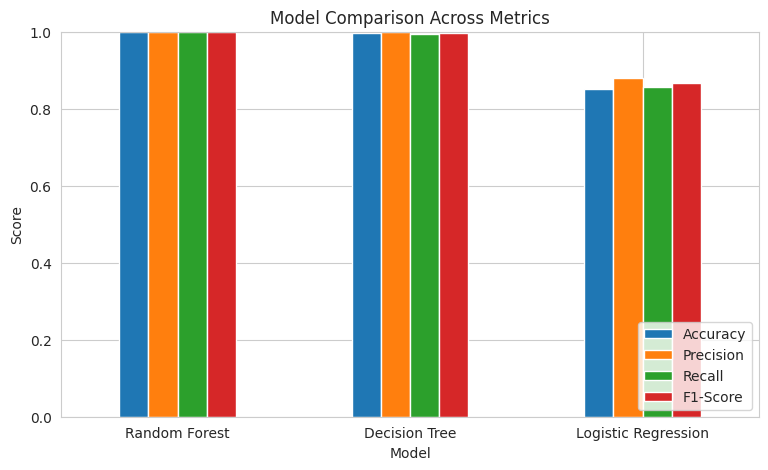

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.999807,0.999940,0.99972,0.999830
1,Decision Tree,0.996836,0.999960,0.99446,0.997202
2,Logistic Regression,0.851044,0.878659,0.85548,0.866915


In [15]:
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', figsize=(9,5)
)
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()

results_df


Best performing model based on F1-Score: Random Forest


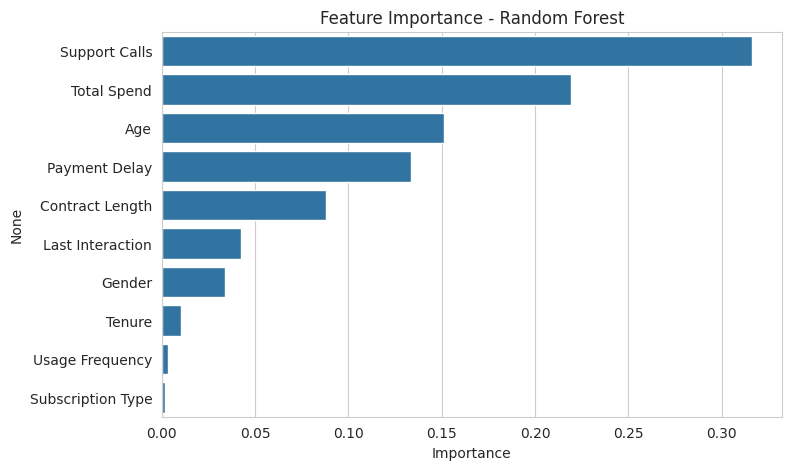

Support Calls        0.316551
Total Spend          0.219520
Age                  0.151200
Payment Delay        0.133675
Contract Length      0.088027
Last Interaction     0.042458
Gender               0.033722
Tenure               0.010033
Usage Frequency      0.003269
Subscription Type    0.001544
dtype: float64


In [16]:
best_model_name = results_df.iloc[0]['Model']
print("Best performing model based on F1-Score:", best_model_name)

if best_model_name in ('Random Forest', 'Decision Tree'):
    model = models[best_model_name][0]
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.show()
    print(importances)


Best performing model based on F1-Score: Random Forest


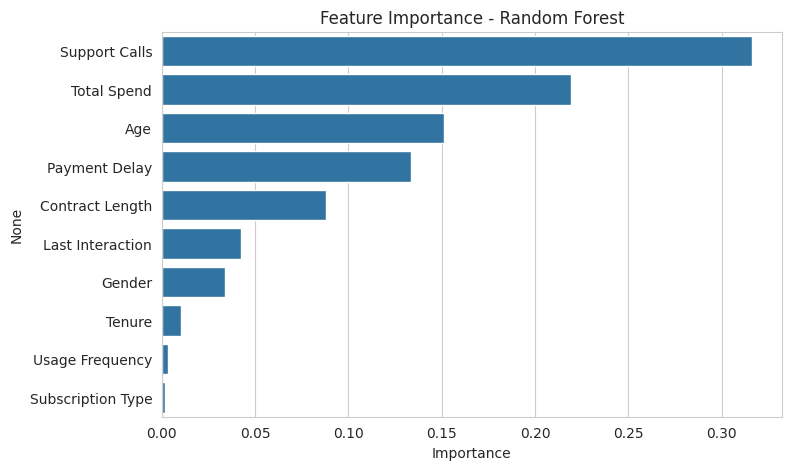

Support Calls        0.316551
Total Spend          0.219520
Age                  0.151200
Payment Delay        0.133675
Contract Length      0.088027
Last Interaction     0.042458
Gender               0.033722
Tenure               0.010033
Usage Frequency      0.003269
Subscription Type    0.001544
dtype: float64


In [17]:
best_model_name = results_df.iloc[0]['Model']
print("Best performing model based on F1-Score:", best_model_name)

if best_model_name in ('Random Forest', 'Decision Tree'):
    model = models[best_model_name][0]
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.show()
    print(importances)
